# House Prices — Data Understanding
Run from a clean kernel. Reusable analysis is in `src.eda`.

In [1]:
from pathlib import Path
import sys
root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(root))
from IPython.display import display, Image
from src.data import read_data
from src.eda import run_eda
train, test = read_data()
report = run_eda()
print('Train/test shape:', train.shape, test.shape)
print('Train dtypes:', report['train_dtypes'])
print('Test dtypes:', report['test_dtypes'])
print('Duplicates:', report['train_duplicates'], report['test_duplicates'])
print('Numeric/categorical:', report['numeric_count'], report['categorical_count'])
print('Numeric columns:', report['numeric_features'])
print('Categorical columns:', report['categorical_features'])

display(train.dtypes.to_frame('dtype').assign(missing=train.isna().sum()))
display(test.dtypes.to_frame('dtype').assign(missing=test.isna().sum()))

Train/test shape: (1460, 81) (1459, 80)
Train dtypes: {'str': 43, 'int64': 35, 'float64': 3}
Test dtypes: {'str': 43, 'int64': 26, 'float64': 11}
Duplicates: 0 0
Numeric/categorical: 36 43
Numeric columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundati

,dtype,missing
Id,int64,0
MSSubClass,int64,0
MSZoning,str,0
LotFrontage,float64,259
LotArea,int64,0
...,...,...
MoSold,int64,0
YrSold,int64,0
SaleType,str,0
SaleCondition,str,0


,dtype,missing
Id,int64,0
MSSubClass,int64,0
MSZoning,str,4
LotFrontage,float64,227
LotArea,int64,0
...,...,...
MiscVal,int64,0
MoSold,int64,0
YrSold,int64,0
SaleType,str,1


In [2]:
from pprint import pprint
print('Target statistics:'); pprint(report['target'])
print('Top train missing:'); pprint(report['top_missing_train'])
print('Top test missing:'); pprint(report['top_missing_test'])
print('Numeric correlations with SalePrice:'); pprint(report['top_correlations'])
print('Outlier candidates (retained):'); pprint(report['outlier_candidates'])

Target statistics:
{'log_skew': 0.12134661989685333,
 'mean': 180921.19589041095,
 'median': 163000.0,
 'skew': 1.8828757597682129,
 'std': 79442.50288288662}
Top train missing:
{'Alley': 1369,
 'BsmtCond': 37,
 'BsmtExposure': 38,
 'BsmtFinType1': 37,
 'BsmtFinType2': 38,
 'BsmtQual': 37,
 'Condition2': 0,
 'Electrical': 1,
 'Fence': 1179,
 'FireplaceQu': 690,
 'GarageCond': 81,
 'GarageFinish': 81,
 'GarageQual': 81,
 'GarageType': 81,
 'GarageYrBlt': 81,
 'LotFrontage': 259,
 'MasVnrArea': 8,
 'MasVnrType': 8,
 'MiscFeature': 1406,
 'PoolQC': 1453}
Top test missing:
{'Alley': 1352,
 'BsmtCond': 45,
 'BsmtExposure': 44,
 'BsmtFinType1': 42,
 'BsmtFinType2': 42,
 'BsmtHalfBath': 2,
 'BsmtQual': 44,
 'Fence': 1169,
 'FireplaceQu': 730,
 'GarageCond': 78,
 'GarageFinish': 78,
 'GarageQual': 78,
 'GarageType': 76,
 'GarageYrBlt': 78,
 'LotFrontage': 227,
 'MSZoning': 4,
 'MasVnrArea': 15,
 'MasVnrType': 16,
 'MiscFeature': 1408,
 'PoolQC': 1456}
Numeric correlations with SalePrice:
{'1st

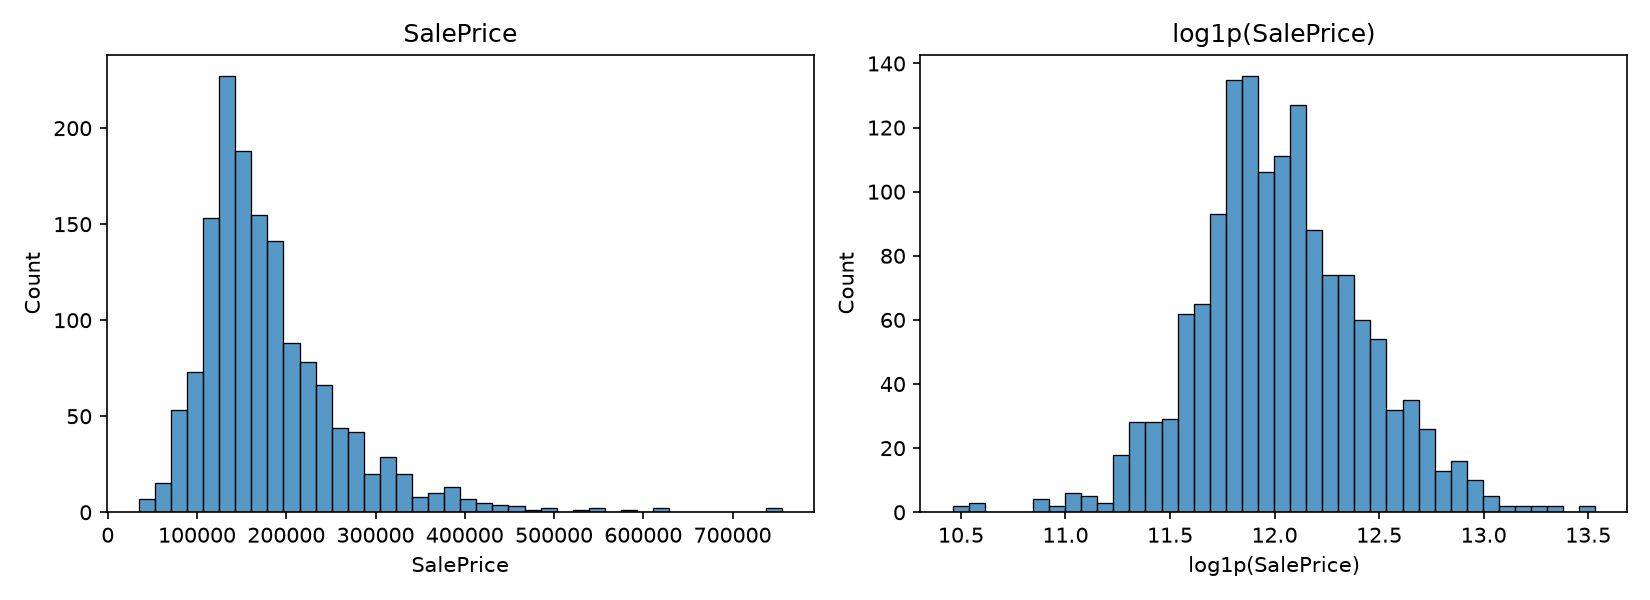

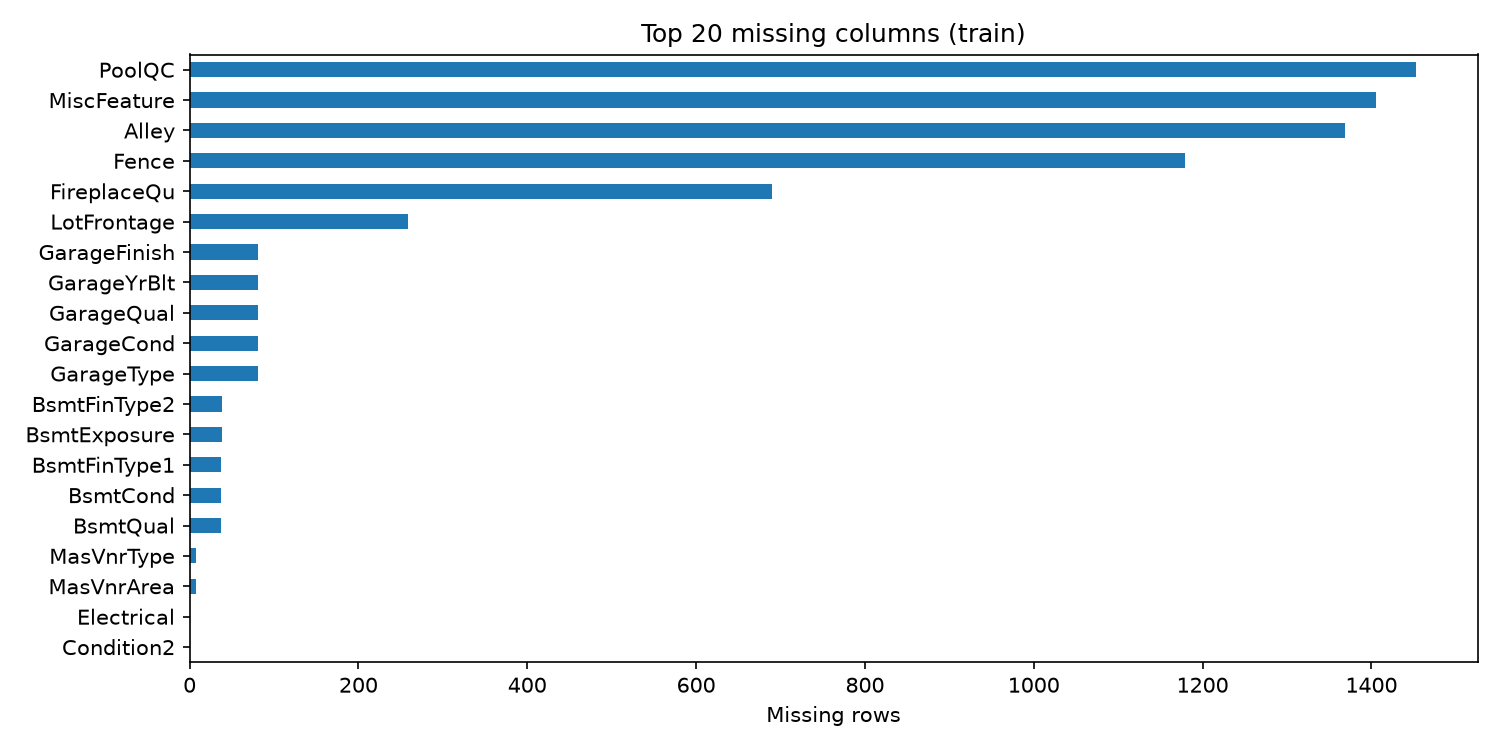

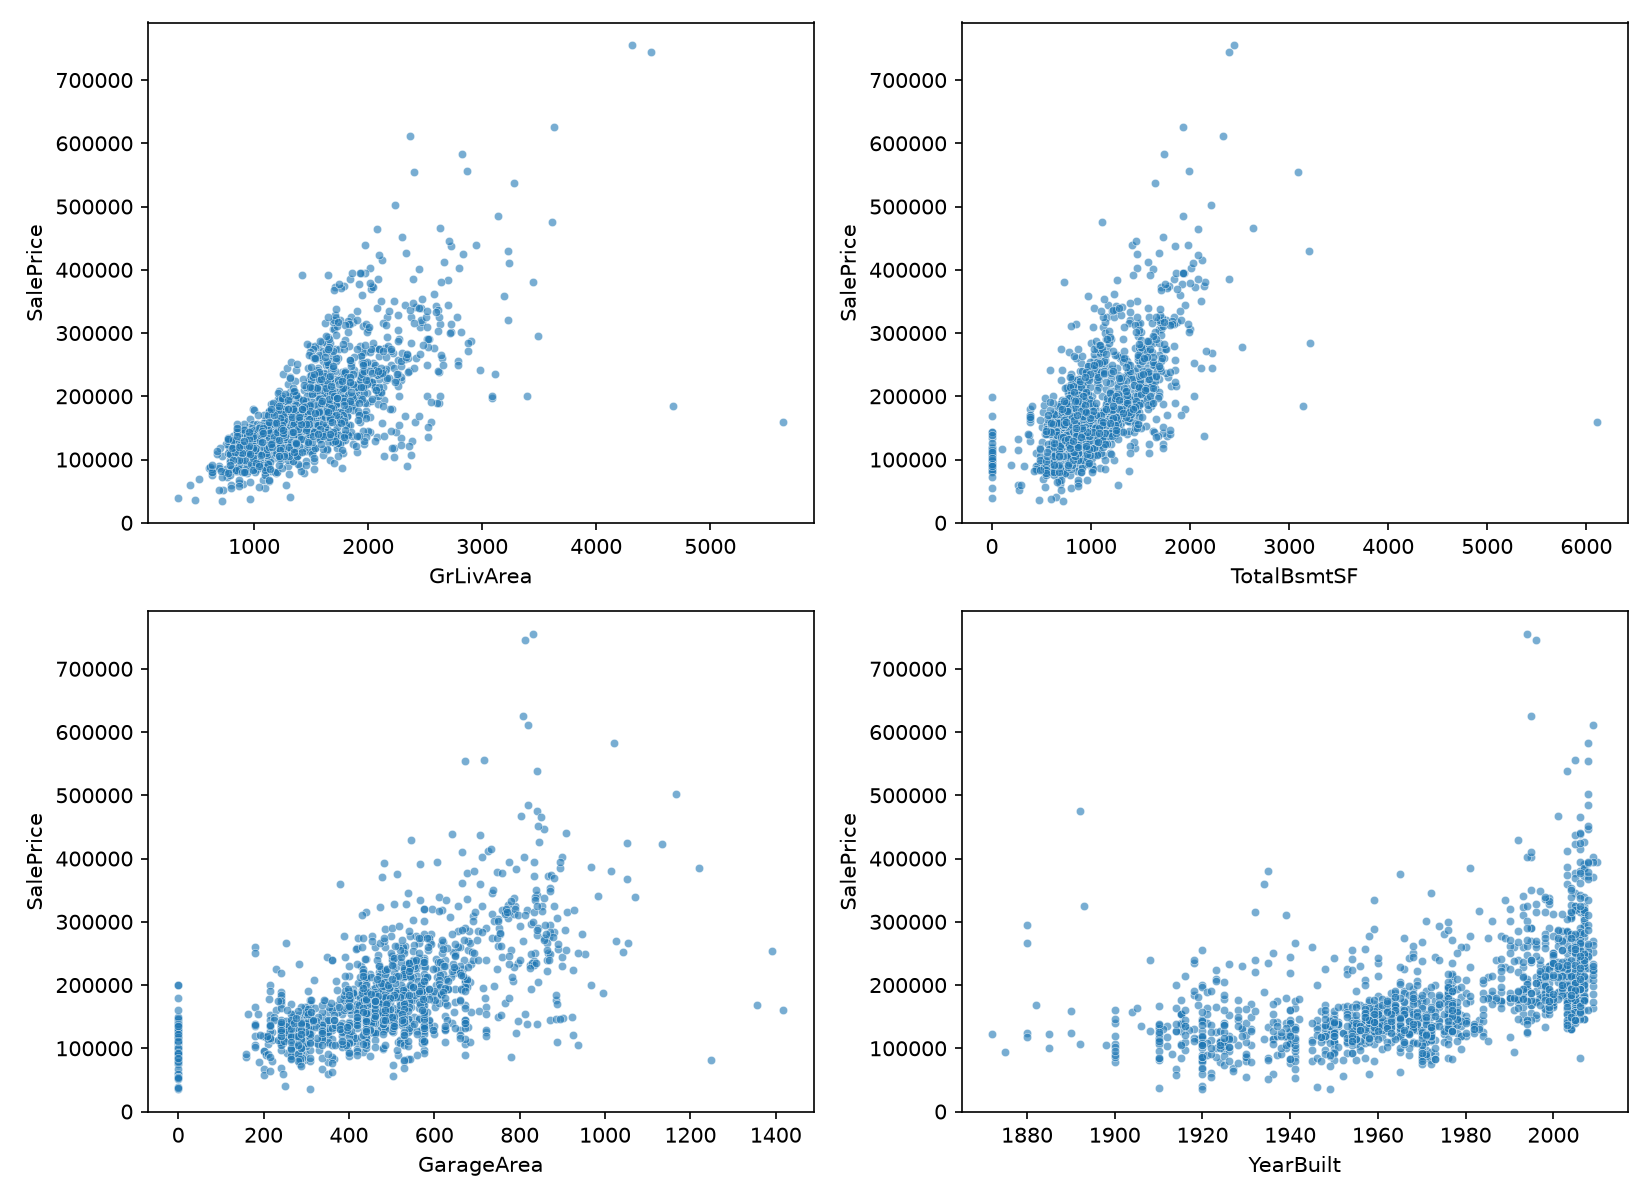

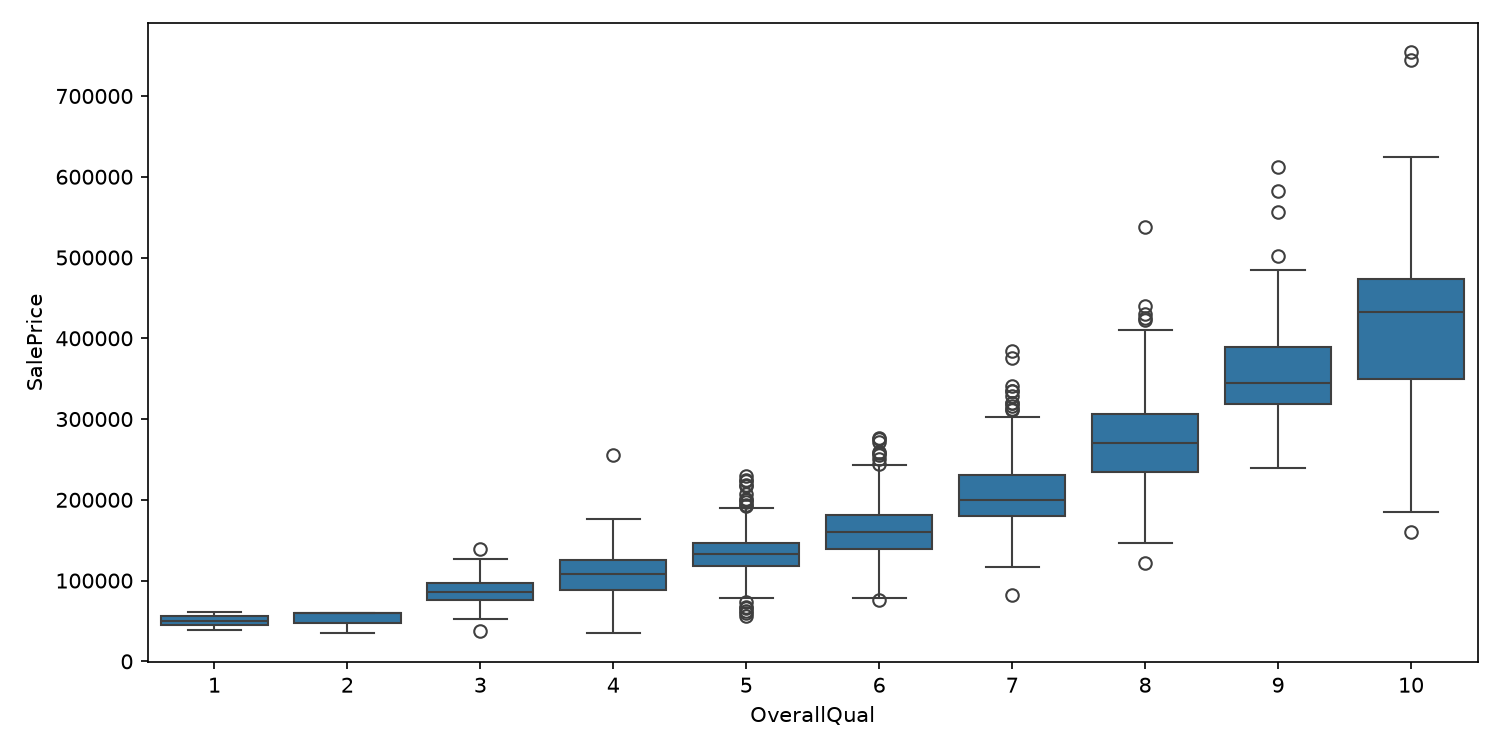

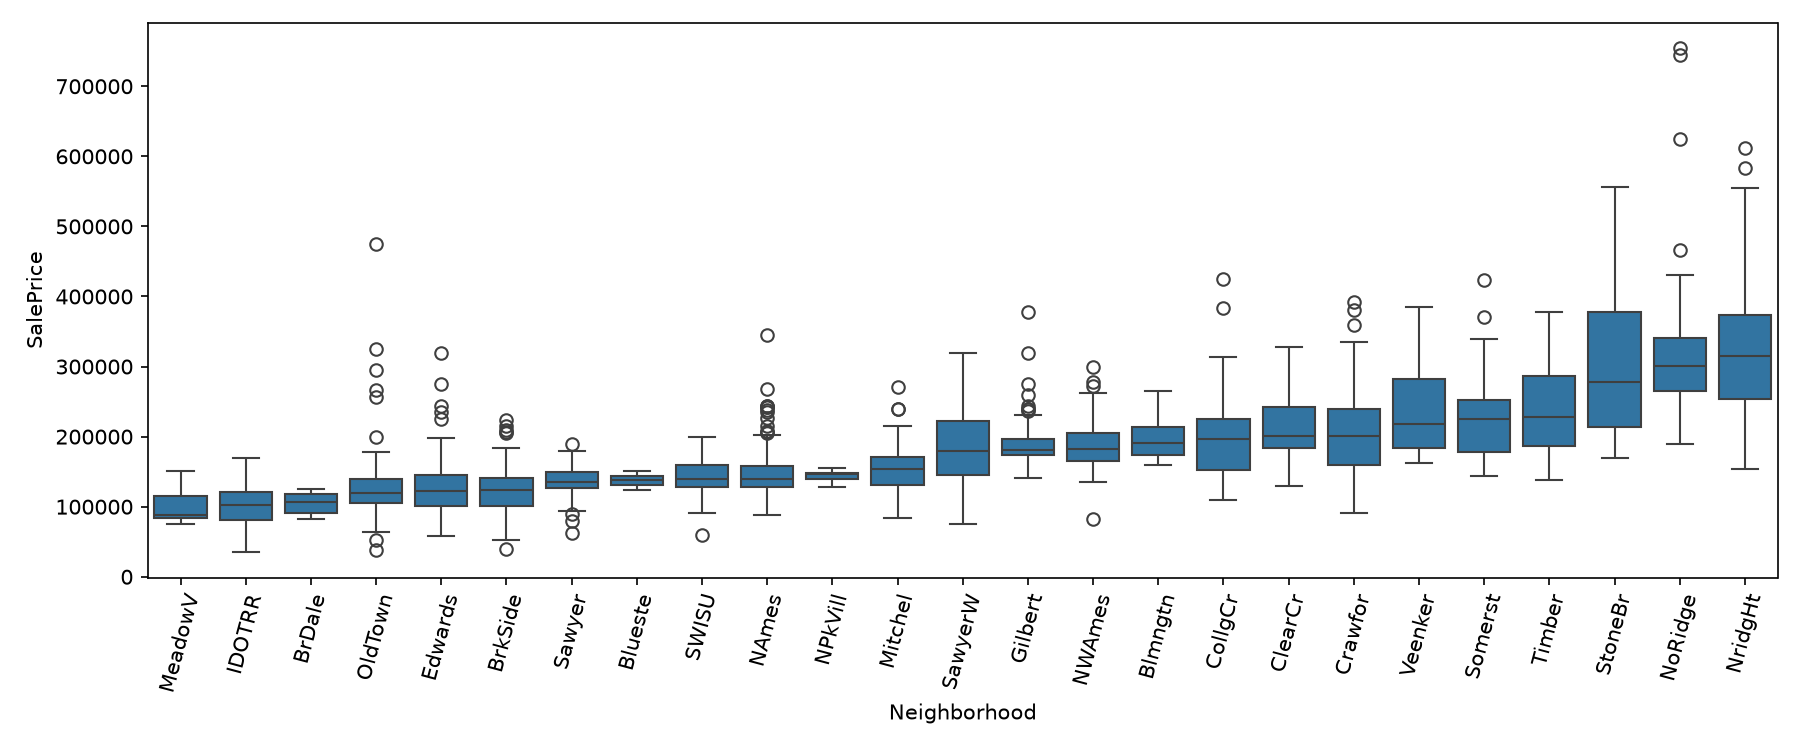

In [3]:
for name in ['target_histograms', 'missing_values', 'numeric_scatter', 'overallqual_boxplot', 'neighborhood_boxplot']:
    display(Image(filename=str(root / 'outputs' / 'figures' / f'{name}.png'))) 

## Interpretation
The target is right skewed; `log1p` makes it nearly symmetric. Quality and living area are the strongest numeric correlates. Several categorical `NA` values describe absent amenities; the baseline imputer treats them as missing, a documented limitation. The unusually large but inexpensive homes with Id 524 and 1299 remain in training pending evidence for removal.